In [1]:
import pandas as pd, numpy as np
import argparse
import pickle
import ast
import pandas as pd
from sklearn.utils import resample
import matplotlib.pyplot as plt
import re

In [2]:
def pickle_to_res(path):
    with open(path, "rb") as f:
        raw_pickle = pickle.load(f)

    results = {}
    answer_prefix="Answer Choice "

    def extract_ans(ans_str, search_substring):
        # Split the string into lines
        lines = ans_str.split("\n")

        for line in lines:
            # Check if the line starts with the specified substring
            if line.startswith(search_substring):
                # If it does, add it to the list of extracted rows
                return line[len(search_substring) :].strip()
        return "ERROR"  # Answer not found

    for k, v in raw_pickle.items():
        if k != 'token_usage':  # Skip token_usage
            qns_idx = ast.literal_eval(k)
            for idx, qn_idx in enumerate(qns_idx):
                results[qn_idx] = extract_ans(
                    v[0], f"{answer_prefix}{idx+1}:"
                )  # We start with question 1
    
    return results

In [3]:
def res_to_vec(res,path=None):
    test_df = pd.read_csv('chexpert_SexBinary_PTX_final_test_df.csv')
    num_errors = 0
    labels, preds, sex = [], [], []
    for i in test_df.itertuples():
        if (i.Index not in res) or (res[i.Index].startswith("ERROR")):
            num_errors += 1

            print(i.Index, f"answer not found")
            continue

        pred_text = res[i.Index]
        ground_truth = "A" if i.Pneumothorax == 1 else "B"
        labels.append(ground_truth)
        preds.append(pred_text)
        sex.append(i.Sex)
        
    print(f"In total {num_errors} errors len = {len(labels)}")
    if path is not None and num_errors != 0:
        print(f"Errors in file at {path}")
    return labels,preds,sex

In [4]:
def calculate_metrics_across_replicates(exp_lists):
    """
    Calculate metrics across technical replicates
    
    Parameters:
    exp_lists: List of 3 lists, where each inner list contains experiments for one technical replicate
               Corresponding experiments should be in the same order in each replicate list
    
    Returns:
    Dictionaries containing means and standard errors for bulk, FST 1/2, and FST 5/6 metrics
    """
    # Initialize data structures for each metric type
    bulk_metrics = {'mean': [], 'stderr': []}
    male_metrics = {'mean': [], 'stderr': []}
    female_metrics = {'mean': [], 'stderr': []}
    
    # Get number of experiments in each replicate
    n_experiments = len(exp_lists[0])
    
    # For each experiment position
    for exp_idx in range(n_experiments):
        # Storage for metrics from each replicate
        bulk_replicate_metrics = []
        male_replicate_metrics = []
        female_replicate_metrics = []
        
        # Process each replicate
        for replicate_list in exp_lists:
            exp = replicate_list[exp_idx]
            results = pickle_to_res(exp)
            labels, preds, sex = res_to_vec(results,path=exp)
            
            # Calculate bulk metrics
            accuracy, tpr, tnr, fscore = calculate_metrics(labels, preds)
            bulk_replicate_metrics.append({
                'accuracy': accuracy,
                'tpr': tpr,
                'fscore': fscore
            })
            
            # Calculate FST 1/2 metrics
            male_labels, male_preds = filter_by_race(labels, preds, sex, 'Male')
            accuracy, tpr, tnr, fscore = calculate_metrics(male_labels, male_preds)
            male_replicate_metrics.append({
                'accuracy': accuracy,
                'tpr': tpr,
                'fscore': fscore
            })
            
            # Calculate FST 5/6 metrics
            female_labels, female_preds = filter_by_race(labels, preds, sex, 'Female')
            accuracy, tpr, tnr, fscore = calculate_metrics(female_labels, female_preds)
            female_replicate_metrics.append({
                'accuracy': accuracy,
                'tpr': tpr,
                'fscore': fscore
            })
        
        # Calculate means and standard errors across replicates
        def calc_mean_stderr(replicate_data, metric):
            values = [rep[metric] for rep in replicate_data]
            return np.mean(values), np.std(values) / np.sqrt(len(values))
        
        # Process bulk metrics
        bulk_means = {}
        bulk_stderrs = {}
        for metric in ['accuracy', 'tpr', 'fscore']:
            mean, stderr = calc_mean_stderr(bulk_replicate_metrics, metric)
            bulk_means[metric] = mean
            bulk_stderrs[metric] = stderr
        bulk_metrics['mean'].append(bulk_means)
        bulk_metrics['stderr'].append(bulk_stderrs)
        
        # Process Male metrics
        male_means = {}
        male_stderrs = {}
        for metric in ['accuracy', 'tpr', 'fscore']:
            mean, stderr = calc_mean_stderr(male_replicate_metrics, metric)
            male_means[metric] = mean
            male_stderrs[metric] = stderr
        male_metrics['mean'].append(male_means)
        male_metrics['stderr'].append(male_stderrs)
        
        # Process Female metrics
        female_means = {}
        female_stderrs = {}
        for metric in ['accuracy', 'tpr', 'fscore']:
            mean, stderr = calc_mean_stderr(female_replicate_metrics, metric)
            female_means[metric] = mean
            female_stderrs[metric] = stderr
        female_metrics['mean'].append(female_means)
        female_metrics['stderr'].append(female_stderrs)
    
    return bulk_metrics, male_metrics, female_metrics

def calculate_metrics(actual, predicted):
    TP = sum((a == 'A' and p == 'A') for a, p in zip(actual, predicted))
    TN = sum((a == 'B' and p == 'B') for a, p in zip(actual, predicted))
    FP = sum((a == 'B' and p == 'A') for a, p in zip(actual, predicted))
    FN = sum((a == 'A' and p == 'B') for a, p in zip(actual, predicted))
    
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    
    # Calculate F1 score
    if precision + recall > 0:
        f1_score = 2 * (precision * recall) / (precision + recall)
    else:
        f1_score = 0
    
    accuracy = (TP + TN) / len(actual)
    tpr = TP / (TP + FN) if (TP + FN) > 0 else 0
    tnr = TN / (TN + FP) if (TN + FP) > 0 else 0
    
    return accuracy, tpr, tnr, f1_score



def filter_by_race(actual, predicted, sex, sex_value):
    filtered_actual = [a for a, r in zip(actual, sex) if r == sex_value]
    filtered_predicted = [p for p, r in zip(predicted, sex) if r == sex_value]
    return filtered_actual, filtered_predicted

In [5]:
def plot_f1_metrics_with_bias(bulk_metrics, male_metrics, female_metrics, shots, use_error_bars=False):
    """
    Plot F1 scores and bias between groups side by side
    
    Parameters:
    bulk_metrics, male_metrics, female_metrics: dictionaries containing means and standard deviations
    shots: list of integers representing the number of shots for each experiment
    use_error_bars: boolean indicating whether to use error bars instead of fill-between for uncertainty
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    # Use custom colors for the lines
    line_colors = ['#1f77b4', '#ff7f0e', '#2ca02c']  # Blue, Orange, Green
    
    # Extract means and standard deviations for F1 scores
    bulk_means = [m['fscore'] for m in bulk_metrics['mean']]
    bulk_stds = [s['fscore'] for s in bulk_metrics['stderr']]
    
    male_means = [m['fscore'] for m in male_metrics['mean']]
    male_stds = [s['fscore'] for s in male_metrics['stderr']]
    
    female_means = [m['fscore'] for m in female_metrics['mean']]
    female_stds = [s['fscore'] for s in female_metrics['stderr']]
    
    # Plot F1 scores
    if use_error_bars:
        ax1.errorbar(shots, bulk_means, yerr=bulk_stds, fmt='o-', 
                    color=line_colors[0], label='Aggregate F1', 
                    linewidth=2, capsize=5, capthick=1, elinewidth=1)
        
        ax1.errorbar(shots, male_means, yerr=male_stds, fmt='s-',
                    color=line_colors[1], label='Male F1',
                    linewidth=2, capsize=5, capthick=1, elinewidth=1)
        
        ax1.errorbar(shots, female_means, yerr=female_stds, fmt='^-',
                    color=line_colors[2], label='Female F1',
                    linewidth=2, capsize=5, capthick=1, elinewidth=1)
    else:
        ax1.plot(shots, bulk_means, 'o-', color=line_colors[0], label='Aggregate F1', linewidth=2)
        ax1.fill_between(shots, 
                        np.array(bulk_means) - np.array(bulk_stds),
                        np.array(bulk_means) + np.array(bulk_stds),
                        color=line_colors[0], alpha=0.2)
        
        ax1.plot(shots, male_means, 's-', color=line_colors[1], label='Male F1', linewidth=2)
        ax1.fill_between(shots,
                        np.array(male_means) - np.array(male_stds),
                        np.array(male_means) + np.array(male_stds),
                        color=line_colors[1], alpha=0.2)
        
        ax1.plot(shots, female_means, '^-', color=line_colors[2], label='Female F1', linewidth=2)
        ax1.fill_between(shots,
                        np.array(female_means) - np.array(female_stds),
                        np.array(female_means) + np.array(female_stds),
                        color=line_colors[2], alpha=0.2)
    
    ax1.set_xlabel('Number of Shots')
    ax1.set_ylabel('F1 Score')
    ax1.set_title('F1 Score by Number of Shots and Patient Sex')
    ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.7)
    
    # Plot F1 score bias
    biases_mean = np.array(male_means) - np.array(female_means)
    biases_std = np.sqrt(np.array(male_stds)**2 + np.array(female_stds)**2)  # Error propagation
    
    if use_error_bars:
        ax2.errorbar(shots, biases_mean, yerr=biases_std, fmt='o-',
                    color='purple', label='Bias (Male - Female F1)',
                    linewidth=2, capsize=5, capthick=1, elinewidth=1)
    else:
        ax2.plot(shots, biases_mean, 'o-', color='purple', 
                label='Bias (Male - Female F1)', linewidth=2)
        ax2.fill_between(shots,
                        biases_mean - biases_std,
                        biases_mean + biases_std,
                        color='purple', alpha=0.2)
    
    ax2.set_xlabel('Number of Shots')
    ax2.set_ylabel('F1 Score Bias')
    ax2.set_title('F1 Score Bias by Number of Shots')
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

In [6]:
exps_rep_1 = [
            "new_chexpert/chexpert_10_1_1_1_1_Gemini1.5_50.pkl",
              "new_chexpert/chexpert_10_5_5_5_5_Gemini1.5_50.pkl",
              "new_chexpert/chexpert_10_10_10_10_10_Gemini1.5_50.pkl",
              "new_chexpert/chexpert_10_20_20_20_20_Gemini1.5_50.pkl",
              "new_chexpert/chexpert_10_30_30_30_30_Gemini1.5_50.pkl",]


exps_rep_2 = [
            "new_chexpert/chexpert_100_1_1_1_1_Gemini1.5_50.pkl",
              "new_chexpert/chexpert_100_5_5_5_5_Gemini1.5_50.pkl",
              "new_chexpert/chexpert_100_10_10_10_10_Gemini1.5_50.pkl",
              "new_chexpert/chexpert_100_20_20_20_20_Gemini1.5_50.pkl",
              "new_chexpert/chexpert_100_30_30_30_30_Gemini1.5_50.pkl",]

exps_rep_3 = [
            "new_chexpert/chexpert_141_1_1_1_1_Gemini1.5_50.pkl",
              "new_chexpert/chexpert_141_5_5_5_5_Gemini1.5_50.pkl",
              "new_chexpert/chexpert_141_10_10_10_10_Gemini1.5_50.pkl",
              "new_chexpert/chexpert_141_20_20_20_20_Gemini1.5_50.pkl",
              "new_chexpert/chexpert_141_30_30_30_30_Gemini1.5_50.pkl",]

exps_list = [exps_rep_1,exps_rep_2,exps_rep_3]

In [7]:
bulk_metrics, male_metrics, female_metrics = calculate_metrics_across_replicates(exps_list)

In total 0 errors len = 100
In total 0 errors len = 100
In total 0 errors len = 100
In total 0 errors len = 100
In total 0 errors len = 100
In total 0 errors len = 100
In total 0 errors len = 100
In total 0 errors len = 100
In total 0 errors len = 100
In total 0 errors len = 100
In total 0 errors len = 100
In total 0 errors len = 100
In total 0 errors len = 100
In total 0 errors len = 100
In total 0 errors len = 100


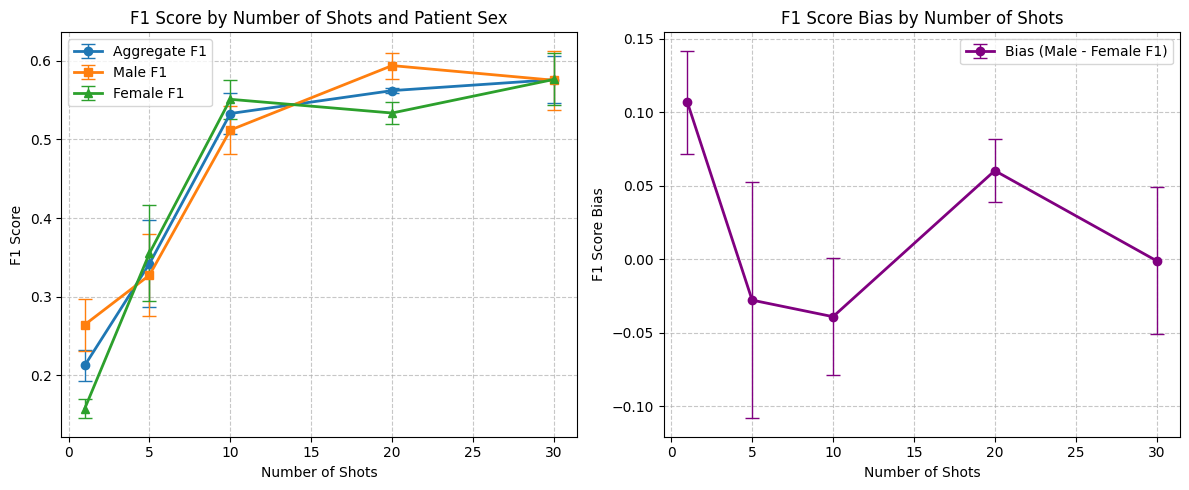

In [8]:
shots= [1,5,10,20,30]
plot_f1_metrics_with_bias(bulk_metrics, male_metrics, female_metrics, shots, use_error_bars=True)

In [9]:
exps_rep_1 = [
            "new_chexpert/chexpert_10_1_1_1_1_gpt-4o-2024-05-13_50.pkl",
              "new_chexpert/chexpert_10_5_5_5_5_gpt-4o-2024-05-13_50.pkl",
              "new_chexpert/chexpert_10_10_10_10_10_gpt-4o-2024-05-13_50.pkl",
              "new_chexpert/chexpert_10_20_20_20_20_gpt-4o-2024-05-13_50.pkl",
              "new_chexpert/chexpert_10_30_30_30_30_gpt-4o-2024-05-13_50.pkl",]


exps_rep_2 = [
            "new_chexpert/chexpert_100_1_1_1_1_gpt-4o-2024-05-13_50.pkl",
              "new_chexpert/chexpert_100_5_5_5_5_gpt-4o-2024-05-13_50.pkl",
              "new_chexpert/chexpert_100_10_10_10_10_gpt-4o-2024-05-13_50.pkl",
              "new_chexpert/chexpert_100_20_20_20_20_gpt-4o-2024-05-13_50.pkl",
              "new_chexpert/chexpert_100_30_30_30_30_gpt-4o-2024-05-13_50.pkl",]

exps_rep_3 = [
            "new_chexpert/chexpert_141_1_1_1_1_gpt-4o-2024-05-13_50.pkl",
              "new_chexpert/chexpert_141_5_5_5_5_gpt-4o-2024-05-13_50.pkl",
              "new_chexpert/chexpert_141_10_10_10_10_gpt-4o-2024-05-13_50.pkl",
              "new_chexpert/chexpert_141_20_20_20_20_gpt-4o-2024-05-13_50.pkl",
              "new_chexpert/chexpert_141_30_30_30_30_gpt-4o-2024-05-13_50.pkl",]

exps_list = [exps_rep_1,exps_rep_2,exps_rep_3]

In [10]:
bulk_metrics, male_metrics, female_metrics = calculate_metrics_across_replicates(exps_list)

24 answer not found
In total 1 errors len = 99
Errors in file at new_chexpert/chexpert_10_1_1_1_1_gpt-4o-2024-05-13_50.pkl
39 answer not found
In total 1 errors len = 99
Errors in file at new_chexpert/chexpert_100_1_1_1_1_gpt-4o-2024-05-13_50.pkl
In total 0 errors len = 100
In total 0 errors len = 100
In total 0 errors len = 100
In total 0 errors len = 100
In total 0 errors len = 100
In total 0 errors len = 100
In total 0 errors len = 100
In total 0 errors len = 100
In total 0 errors len = 100
In total 0 errors len = 100
In total 0 errors len = 100
In total 0 errors len = 100
In total 0 errors len = 100


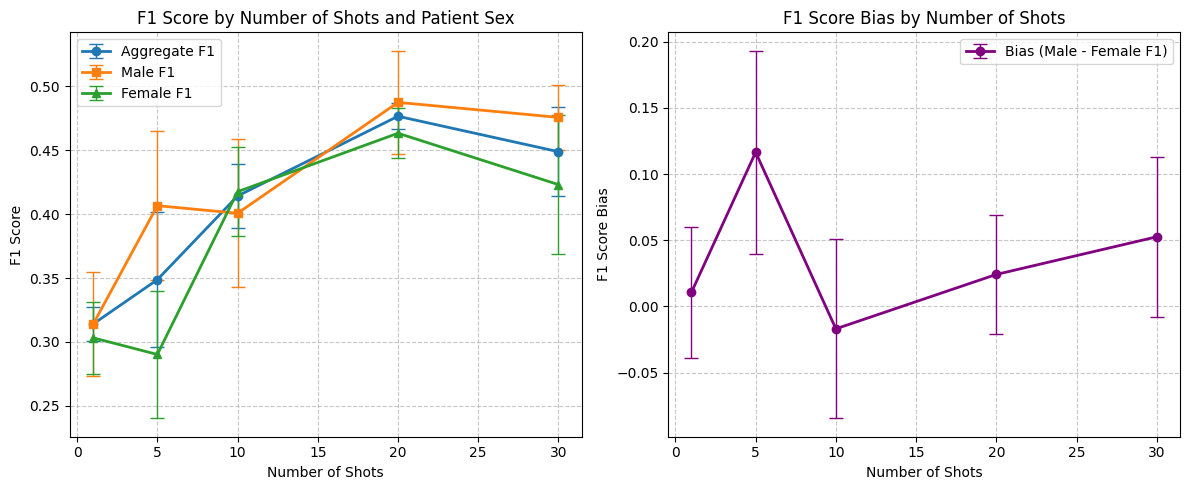

In [11]:
shots= [1,5,10,20,30]
plot_f1_metrics_with_bias(bulk_metrics, male_metrics, female_metrics, shots, use_error_bars=True)